## Question 4

In [2]:
import numpy as np
import cvxpy as cp

n = 200
m = int(0.1 * n**2)
tolerance = 0.01
trials = 20

def generate_matrix(n):
    y = np.random.normal(0, 1, n)
    z = np.random.uniform(0, 1, n)
    return np.outer(y, z)

success_count = 0

for trial in range(trials):
    X_star = generate_matrix(n)
    indices = np.random.choice(n**2, m, replace=False)
    K = np.unravel_index(indices, (n, n))
    measured_entries = X_star[K]
    
    X_hat = cp.Variable((n, n))
    constraints = [X_hat[K] == measured_entries]
    objective = cp.Minimize(cp.normNuc(X_hat))
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS)
    
    if problem.status == cp.OPTIMAL:
        error = np.linalg.norm(X_star - X_hat.value, ord='fro')
        if error <= tolerance:
            success_count += 1

success_rate = success_count / trials
print(f"Empirical probability of success: {success_rate:.2f}")


Empirical probability of success: 1.00


## Question 5


# Part 1: Global Minimum


In [3]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

n = 1000
a = np.random.uniform(0, 1, n)
b = np.random.uniform(0, 1, n)

# Objective function and its derivatives
def objective_function(x):
    term1 = np.sum(x**4)
    term2 = (np.sum(a * x))**2
    term3 = np.sum(b * x)
    return term1 + term2 + term3

def gradient(x):
    term1_grad = 4 * x**3
    term2_grad = 2 * np.sum(a * x) * a
    term3_grad = b
    return term1_grad + term2_grad + term3_grad

def hessian(x):
    term1_hess = np.diag(12 * x**2)
    term2_hess = 2 * np.outer(a, a)
    return term1_hess + term2_hess


In [4]:
x_cvx = cp.Variable(n)
objective = cp.Minimize(cp.sum(x_cvx**4) + cp.sum(cp.multiply(a, x_cvx))**2 + cp.sum(cp.multiply(b, x_cvx)))
constraints = []
problem = cp.Problem(objective, constraints)
problem.solve()
x_star = x_cvx.value


In [5]:
print(f"Objective value at x*: {objective_function(x_star)}")


Objective value at x*: -113.69611176640154


# Part 2.1

In [6]:
def newtons_method(x0, max_iters, tol, step_size):
    x = x0
    for _ in range(max_iters):
        grad = gradient(x)
        if np.linalg.norm(grad) < tol:
            break
        hess = hessian(x)
        delta_x = -np.linalg.solve(hess, grad)
        x = x + step_size * delta_x
    return x

x0 = np.ones(n)
x_constant = newtons_method(x0, 100, 1e-4, 0.1)


In [8]:
print(f"Objective value at constant step size solution: {objective_function(x_constant)}")
print(f"Norm of gradient: {np.linalg.norm(gradient(x_constant))}")


Objective value at constant step size solution: 4.8074753099256104e+16
Norm of gradient: 12254576457972.762


# Part 2.2

In [10]:
def backtracking_newtons_method(x0, max_iters, tol, s, alpha):
    x = x0
    for _ in range(max_iters):
        grad = gradient(x)
        if np.linalg.norm(grad) < tol:
            break
        hess = hessian(x)
        delta_x = -np.linalg.solve(hess, grad)
        m = 0
        while objective_function(x + s * alpha**m * delta_x) >= objective_function(x):
            m += 1
        x = x + s * alpha**m * delta_x
    return x

x_adaptive = backtracking_newtons_method(x0, 100, 1e-4, 0.5, 0.5)


In [11]:
print(f"Objective value at adaptive step size solution: {objective_function(x_adaptive)}")
print(f"Norm of gradient: {np.linalg.norm(gradient(x_adaptive))}")


Objective value at adaptive step size solution: -113.67250675590728
Norm of gradient: 0.18892259319353757


# Part 2.2 Plotting Convergence

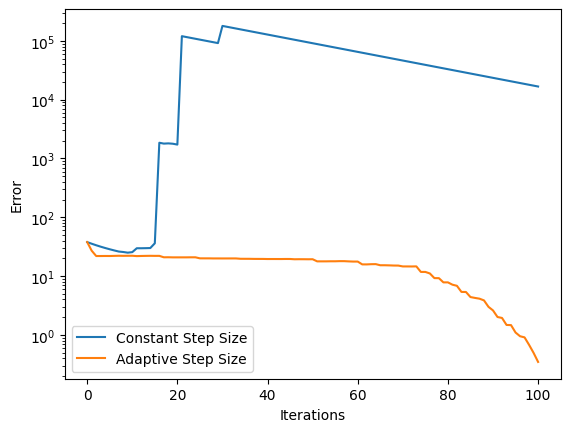

In [12]:
errors_constant = [np.linalg.norm(x_star - x0)]
errors_adaptive = [np.linalg.norm(x_star - x0)]

x = x0
for _ in range(100):
    grad = gradient(x)
    hess = hessian(x)
    delta_x = -np.linalg.solve(hess, grad)
    x = x + 0.1 * delta_x
    errors_constant.append(np.linalg.norm(x_star - x))

x = x0
for _ in range(100):
    grad = gradient(x)
    hess = hessian(x)
    delta_x = -np.linalg.solve(hess, grad)
    m = 0
    while objective_function(x + 0.5 * 0.5**m * delta_x) >= objective_function(x):
        m += 1
    x = x + 0.5 * 0.5**m * delta_x
    errors_adaptive.append(np.linalg.norm(x_star - x))

plt.semilogy(errors_constant, label="Constant Step Size")
plt.semilogy(errors_adaptive, label="Adaptive Step Size")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


In [13]:
print(f"Objective value difference (CVXPY vs Constant): {np.abs(objective_function(x_star) - objective_function(x_constant))}")
print(f"Objective value difference (CVXPY vs Adaptive): {np.abs(objective_function(x_star) - objective_function(x_adaptive))}")


Objective value difference (CVXPY vs Constant): 4.8074753099256216e+16
Objective value difference (CVXPY vs Adaptive): 0.02360501049426489
